# En este dataset se pretende desarrollar un modelo de clasificación para los diferentes tipos de ensimas quitanasas de las que se tienen muestra

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.utils import plot_model

In [5]:
def reduce_memory_usage(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    return df

In [6]:
class ProportionError(Exception):
    def __init__(self):
        super().__init__('Las proporciones deben sumar 1')

def muestra_estratificada(data: pd.DataFrame, column: str, propor_w: pd.Series, replace=False) -> pd.DataFrame:
    #Recibe un dataframe, el nombre de una columna y una series de pandas con las proporciones de cada valor
    #y se encarga de obtener una muestra de los datos con las proporciones deseadas
    if sum(propor_w) != 1: raise ProportionError()
    total = len(data) # variable para el tamano de la muestra resultante, se ira ajustando para machear con las proporciones
    part_r = data[column].value_counts() # cantidad de instancias que tiene cada valor de la variable categorica
    result = pd.DataFrame(columns=data.columns, data=[])
    if replace:
        for i in propor_w.keys():
            temp = data[data[column] == i]
            result = pd.concat([result, temp.sample(replace=True, n= int(propor_w[i] * total))])
    else:
        check = True # variable para verificar si el tamano es el adecuado para las proporciones
        while check:
            check = False
            max_dif = 0
            for i in part_r.keys():
            #aqui se verifica si la cantidad de muestras de un valor determinado son menores que las muestras necesarias
            #para machear con la proporcion esperada si ese es el caso se le resta la diferencia a la variable total
            #indicando que la muestra total debe ser menor
                dif = part_r[i] - int(propor_w[i] * total)
                if max_dif > dif: max_dif = dif
            if max_dif < 0:
                total += max_dif
                check = True
        for i in propor_w.keys():
            temp = data[data[column] == i]
            result = pd.concat([result, temp.iloc[:int(propor_w[i] * total)]])
    return result

In [7]:
df_train = pd.read_csv('/content/Ensimas/datasets/large_datasets/train_descriptores.csv')
df_train = reduce_memory_usage(df_train)
df_train.head(5)

,Unnamed: 0,id_uniprot,sequence,ec_number,IsEnzime,family,A,R,N,D,...,_HydrophobicityD2001,_HydrophobicityD2025,_HydrophobicityD2050,_HydrophobicityD2075,_HydrophobicityD2100,_HydrophobicityD3001,_HydrophobicityD3025,_HydrophobicityD3050,_HydrophobicityD3075,_HydrophobicityD3100
0,1,Q66C72,MAQVAKKILVTCALPYANGSIHLGHMLEHIQADIWVRFQRMRGNQV...,6.1.1.10,1,6,9.630,4.593,3.852,7.704,...,0.296,24.444000,48.889000,74.667000,99.406998,0.148,26.370001,50.369999,75.556000,99.851997
1,2,Q3Z4P3,MATLFIADLHLCVEEPAITAGFLRFLAGEARKADALYILGDLFEAW...,3.6.1.54,1,3,12.500,6.250,2.917,5.417,...,0.833,23.333000,48.750000,75.833000,99.583000,0.417,22.917000,47.083000,74.583000,100.000000
2,4,Q1JHB8,MEALKKIAGVTAAQYVTDGMTIGLGTGSTAYYFVEEIGRRVKQEGL...,5.3.1.6,1,5,7.930,2.643,1.322,8.370,...,1.322,19.823999,43.612000,70.925003,100.000000,0.441,29.075001,54.185001,77.532997,97.357002
3,6,P50362,MAAMMQKSAFTGSAVSSKSGVRAKAARAVVDVRAEKKIRVAINGFG...,1.2.1.13,1,1,10.963,4.545,3.476,6.952,...,0.535,23.797001,50.266998,71.389999,100.000000,0.267,25.936001,50.801998,75.667999,99.733002
4,7,A5E7U2,MAETETNPLVVFATVATIIISFVTLYFFKQSAKSSTTSSSSSSSSK...,1.6.2.2,1,1,6.000,2.000,4.333,4.667,...,0.667,18.667000,44.333000,72.667000,98.000000,0.333,26.333000,52.000000,77.000000,100.000000


In [8]:
df_valid = pd.read_csv('/content/Ensimas/datasets/large_datasets/valid_descriptores.csv')
df_valid = reduce_memory_usage(df_valid)
df_valid.head(5)

,Unnamed: 0,id_uniprot,sequence,ec_number,IsEnzime,family,A,R,N,D,...,_HydrophobicityD2001,_HydrophobicityD2025,_HydrophobicityD2050,_HydrophobicityD2075,_HydrophobicityD2100,_HydrophobicityD3001,_HydrophobicityD3025,_HydrophobicityD3050,_HydrophobicityD3075,_HydrophobicityD3100
0,2,Q68WM5,MIKKEIIILCGPTASGKSYLGHELAKAYGCEIINIDSMQVYREIPI...,2.5.1.75,1,2,5.788,4.502,5.788,4.502,...,3.537,18.327999,38.584999,72.668999,100.000000,0.322,24.115999,46.945000,72.347000,99.357002
1,3,Q6HJF2,MKKVDVKESAVGRETRIRKQWNEQSIFEQSIQNREGAQSFVFYEGP...,6.1.1.5,1,6,6.099,4.066,4.647,5.615,...,0.871,22.072001,45.499001,70.377998,99.903000,0.097,26.233999,51.500000,75.799004,99.612999
2,8,Q2GFJ2,MSSKCESVKPQLVNEVLGYWDLLKPKIMYLVVLTGITGMIIAPGNI...,2.5.1.141,1,2,6.441,1.695,3.051,1.695,...,0.678,22.712000,48.813999,71.863998,99.661003,0.339,26.780001,54.576000,77.966003,100.000000
3,9,A4X398,MHEVDIAVVGAGPAGLFAAYYAGFRGLSVAVVDALPEPGGQITAMY...,1.18.1.2,1,1,15.528,6.211,1.553,4.969,...,0.621,23.913000,48.757999,73.913002,100.000000,0.311,23.601999,47.515999,72.981003,97.515999
4,10,A8LLD7,MIIGIGTDLANIERIERTLERFGDRFRHRVFTEREQRKADSRQQTA...,2.7.8.7,1,2,14.388,10.072,1.439,4.317,...,2.878,34.532001,59.712002,79.856003,100.000000,0.719,15.827000,51.078999,72.662003,94.963997


## Vamos a apreciar cuantas clases o tipos de ensimas se tienen

In [9]:
proporciones_train = df_train['family'].value_counts(normalize=True).reset_index()
proporciones_valid = df_valid['family'].value_counts(normalize=True).reset_index()

In [10]:
proporciones_train

,family,proportion
0,2,0.363484
1,3,0.185748
2,1,0.121666
3,6,0.121612
4,4,0.103297
5,5,0.064424
6,7,0.039770


In [11]:
print(f"Cantidad de clases: {len(proporciones_train)}")

Cantidad de clases: 7


In [12]:
proporciones_train.columns = ['class', 'frequency']
proporciones_valid.columns = ['class', 'frequency']

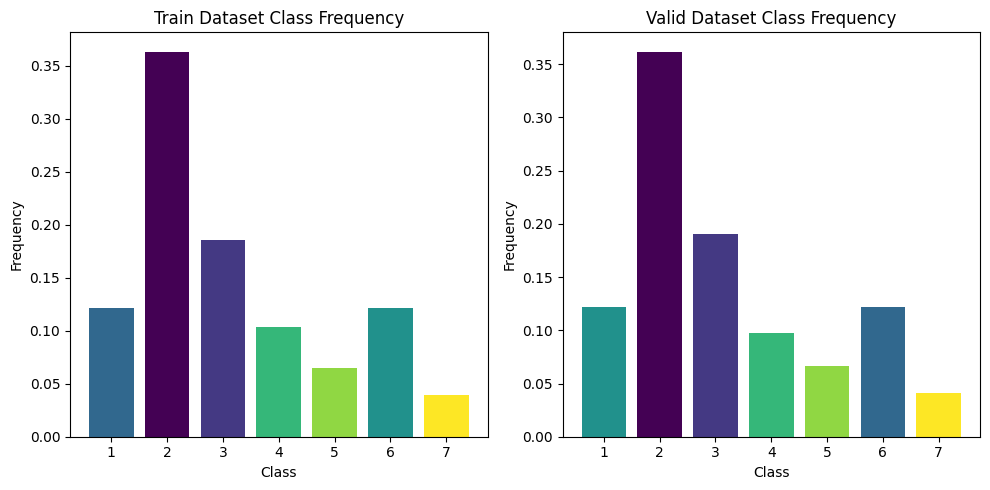

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, len(proporciones_train)))
axes[0].bar(proporciones_train['class'], proporciones_train['frequency'], color=colors)
axes[0].set_title('Train Dataset Class Frequency')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Frequency')
axes[1].bar(proporciones_valid['class'], proporciones_valid['frequency'], color=colors)
axes[1].set_title('Valid Dataset Class Frequency')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Como se puede apreciar los datos de entrenamiento y prueba tienen proporciones similares, sin embargo existe una desproporcion entre las clases a clasificar lo que puede causar un sesgo del modelo hacia las clases de las que mas se tienen muestras. Para corregir esto se va a usar SMOTE que es una tecnica de oversampling para balancear las muestras.

In [14]:
!pip install imbalanced-learn

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
smote = SMOTE(random_state=42)

# Aplicar SMOTE a los datos de entrenamiento, a las clases con menos frecuencias
X_train, y_train = smote.fit_resample((df_train.iloc[:,6:])[df_train['family'].isin([4, 5, 7])], (df_train['family'])[df_train['family'].isin([4, 5, 7])])

In [17]:
y_train.value_counts()

,count
family,
5,17275
4,17275
7,17275


In [18]:
X_train["family"] = y_train.copy()
df_train = pd.concat([X_train, (df_train.iloc[:,5:])[df_train["family"].isin([1, 2, 3, 6])]])
df_train.dropna()

<ipython-input-18-5470a91fc02b>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train["family"] = y_train.copy()


,A,R,N,D,C,E,Q,G,H,I,...,_HydrophobicityD2025,_HydrophobicityD2050,_HydrophobicityD2075,_HydrophobicityD2100,_HydrophobicityD3001,_HydrophobicityD3025,_HydrophobicityD3050,_HydrophobicityD3075,_HydrophobicityD3100,family
0,7.930,2.643,1.322,8.370,0.441,5.727,2.643,11.454,1.322,6.167,...,19.823999,43.612000,70.925003,100.000000,0.441,29.075001,54.185001,77.532997,97.357002,5
1,5.405,5.706,3.904,6.907,2.102,7.508,3.303,6.907,2.402,9.009,...,29.129000,57.356998,74.174004,100.000000,0.300,18.618999,46.245998,73.874001,99.399002,4
2,8.092,2.312,1.156,2.890,0.578,3.468,0.000,13.873,0.578,1.734,...,20.809000,43.353001,68.208000,99.421997,0.578,24.277000,50.867001,75.144997,100.000000,7
3,8.392,3.846,2.797,2.098,0.350,3.147,2.098,9.441,3.147,8.042,...,29.371000,54.895000,80.419998,99.650002,0.350,20.629000,44.405998,63.986000,100.000000,7
4,7.752,4.651,4.264,6.202,1.163,7.752,3.876,8.527,1.938,6.589,...,22.481001,49.612000,79.070000,100.000000,0.388,22.093000,46.898998,71.705002,99.612000,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167231,8.696,3.478,2.609,4.348,0.870,9.565,3.478,6.957,0.870,6.087,...,24.348000,50.435001,73.913002,94.782997,0.870,20.000000,48.695999,80.000000,100.000000,3
167233,6.329,4.747,5.538,5.696,1.582,5.854,3.639,9.494,3.639,7.437,...,21.993999,49.525002,72.626999,99.842003,0.158,27.690001,52.373001,74.842003,100.000000,2
167234,13.873,6.358,2.890,4.624,1.734,2.312,7.514,9.249,1.734,8.671,...,24.277000,54.912998,79.768997,99.421997,0.578,19.075001,39.883999,70.519997,92.486000,3
167235,7.967,2.602,3.902,6.341,0.813,5.203,2.764,8.943,3.577,8.455,...,21.462999,47.966999,70.406998,98.862000,0.163,26.992001,52.520000,78.049004,100.000000,2


In [19]:
df_train.columns

Index(['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I',
       ...
       '_HydrophobicityD2025', '_HydrophobicityD2050', '_HydrophobicityD2075',
       '_HydrophobicityD2100', '_HydrophobicityD3001', '_HydrophobicityD3025',
       '_HydrophobicityD3050', '_HydrophobicityD3075', '_HydrophobicityD3100',
       'family'],
      dtype='object', length=888)

Luego se obtiene una muestra estratificada ya con las proporciones adecuadas

In [20]:
proporcion = (df_train['family'].value_counts()/ len(df_train)).sort_values(ascending=True)
acum = 0
for i, v in enumerate(proporcion.keys()):
  proporcion[v] = 1/len(proporcion) if (i != len(proporcion)-1) else 1-acum
  acum += 1/len(proporcion)
df_train = muestra_estratificada(df_train, 'family', proporcion)

<ipython-input-6-2d295bfa0586>:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, temp.iloc[:int(propor_w[i] * total)]])


Luego se repite el procedimiento para los datos de validacion

In [21]:
X_valid, y_valid = smote.fit_resample((df_valid.iloc[:,6:])[df_valid['family'].isin([4, 5, 7])], (df_valid['family'])[df_valid['family'].isin([4, 5, 7])])
X_valid["family"] = y_valid.copy()
df_valid = pd.concat([X_valid, (df_valid.iloc[:, 5:])[df_valid["family"].isin([1, 2, 3, 6])]])
df_valid.dropna()
proporcion = (df_valid['family'].value_counts()/ len(df_valid)).sort_values(ascending=True)
acum = 0
for i, v in enumerate(proporcion.keys()):
  proporcion[v] = 1/len(proporcion) if (i != len(proporcion)-1) else 1-acum
  acum += 1/len(proporcion)
df_valid = muestra_estratificada(df_valid, 'family', proporcion)

<ipython-input-21-0701e5ab627f>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_valid["family"] = y_valid.copy()
<ipython-input-6-2d295bfa0586>:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, temp.iloc[:int(propor_w[i] * total)]])


In [22]:
proporciones_train = df_train['family'].value_counts(normalize=True).reset_index()
proporciones_valid = df_valid['family'].value_counts(normalize=True).reset_index()
proporciones_train.columns = ['class', 'frequency']
proporciones_valid.columns = ['class', 'frequency']

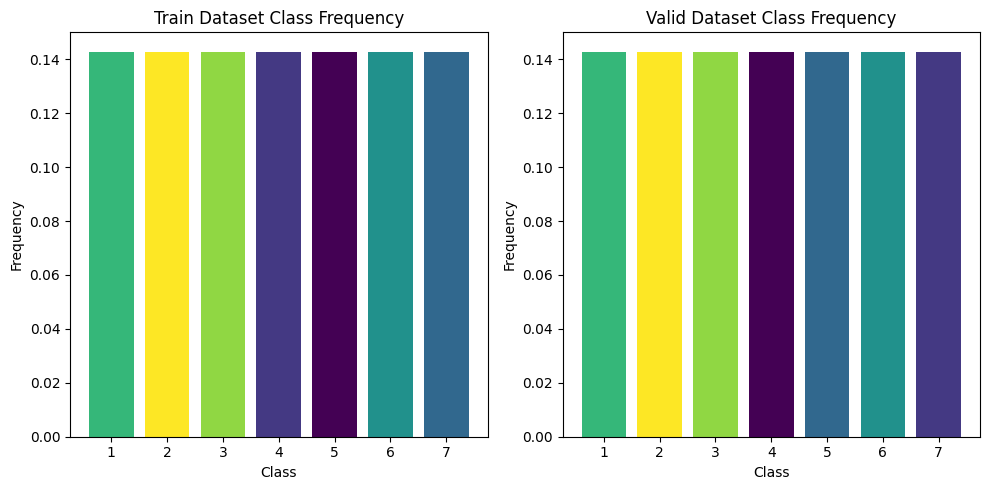

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, len(proporciones_train)))
axes[0].bar(proporciones_train['class'], proporciones_train['frequency'], color=colors)
axes[0].set_title('Train Dataset Class Frequency')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Frequency')
axes[1].bar(proporciones_valid['class'], proporciones_valid['frequency'], color=colors)
axes[1].set_title('Valid Dataset Class Frequency')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Ahora se procede a normalizar los datos para que el modelo converja mas rapido

In [24]:
X_train = df_train.iloc[:,:-1].to_numpy()
y_train = df_train['family'].to_numpy()
X_valid = df_valid.iloc[:,:-1].to_numpy()
y_valid = df_valid['family'].to_numpy()

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
s_scaler = StandardScaler()

In [27]:
s_scaler.fit(X_train)
X_train = s_scaler.transform(X_train)

In [28]:
X_valid = s_scaler.transform(X_valid)

In [29]:
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_valid = encoder.fit_transform(y_valid.reshape(-1, 1))

In [30]:
X_train.shape

(120925, 887)

## Ahora se procede a contruir el modelo que efectuara la clasificación

Para esta clasificación se va a crear una red neuronal profunda

In [31]:
model = Sequential()
model.add(layers.Input(shape=(887,)))
model.add(layers.Dense(256))
model.add(layers.PReLU())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(128))
model.add(layers.PReLU())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(64))
model.add(layers.PReLU())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(7, activation='softmax'))

In [32]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [33]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1, restore_best_weights=True)

In [34]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_valid, y_valid), callbacks=[early_stopping])

Epoch 1/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - accuracy: 0.5191 - loss: 1.2953 - val_accuracy: 0.7681 - val_loss: 0.6711
Epoch 2/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7481 - loss: 0.7181 - val_accuracy: 0.8252 - val_loss: 0.5247
Epoch 3/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8019 - loss: 0.5788 - val_accuracy: 0.8385 - val_loss: 0.4601
Epoch 4/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8273 - loss: 0.5004 - val_accuracy: 0.8624 - val_loss: 0.4070
Epoch 5/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8474 - loss: 0.4459 - val_accuracy: 0.8734 - val_loss: 0.3774
Epoch 6/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8585 - loss: 0.4156 - val_accuracy: 0.8734 - val_loss: 0.3718
Epoch 7/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8698 - loss: 0.3845 - val_accuracy: 0.8820 - val_loss: 0.3504
Epoch 8/50
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8763 - loss

In [35]:
print(model.evaluate(X_train, y_train))
print(model.evaluate(X_valid, y_valid))

3779/3779 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9736 - loss: 0.0862
[0.12150096893310547, 0.9641017317771912]
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9241 - loss: 0.2426
[0.2815457880496979, 0.9125138521194458]


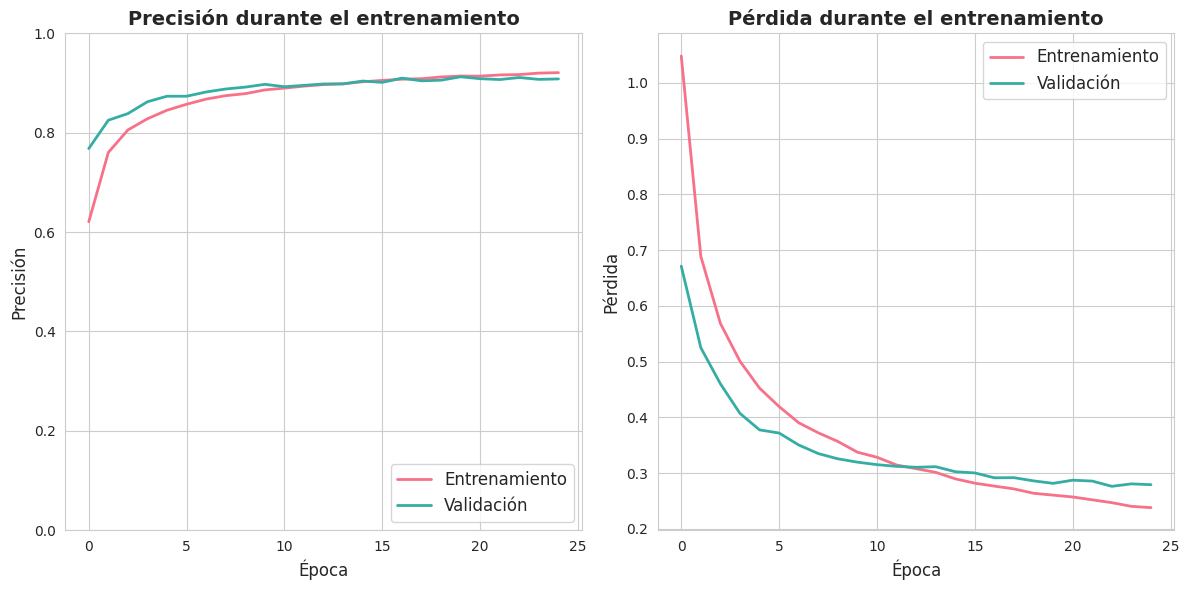

In [38]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", 2)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', color=colors[0], linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación', color=colors[1], linewidth=2)
plt.title('Precisión durante el entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.ylim([0, 1])
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color=colors[0], linewidth=2)
plt.plot(history.history['val_loss'], label='Validación', color=colors[1], linewidth=2)
plt.title('Pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

## Ahora vamos a probar el modelo con los datos de prueba

In [45]:
df_test = pd.read_csv('/content/Ensimas/datasets/large_datasets/test_descriptores.csv')
df_test = reduce_memory_usage(df_test)
df_test.head(5)

,Unnamed: 0,id_uniprot,sequence,ec_number,IsEnzime,family,A,R,N,D,...,_HydrophobicityD2001,_HydrophobicityD2025,_HydrophobicityD2050,_HydrophobicityD2075,_HydrophobicityD2100,_HydrophobicityD3001,_HydrophobicityD3025,_HydrophobicityD3050,_HydrophobicityD3075,_HydrophobicityD3100
0,2,Q41224,MMTRGATRMTRTVLGHMGPRYFSTAIFRNDAGTGVMSGAAVFMHGV...,1.10.3.11,1,1,9.348,5.666,3.116,5.382,...,0.850,19.830000,43.909000,73.653999,100.000000,0.283,29.462000,53.824001,72.237999,99.150002
1,6,P40288,MYKDLEGKVVVITGSSTGLGKSMAIRFATEKAKVVVNYRSKEDEAN...,1.1.1.47,1,1,9.962,2.299,5.364,4.215,...,0.766,29.885000,60.153000,82.759003,100.000000,0.383,25.287001,46.360001,69.348999,98.084000
2,11,Q31W94,MATNLRGVMAALLTPFDQQQALDKASLRRLVQFNIQQGIDGLYVGG...,4.1.3.3,1,4,8.418,4.040,2.357,5.387,...,0.673,27.273001,46.127998,69.024002,100.000000,0.337,24.916000,50.167999,77.103996,98.653000
3,12,Q05592,MKKALLVVSFGTSYHDTCEKNIVACERDLAASCPDRDLFRAFTSGM...,4.99.1.3,1,4,11.742,6.061,2.652,7.197,...,1.515,27.652000,56.438999,78.408997,100.000000,0.379,23.864000,46.970001,73.863998,98.485001
4,15,Q04TR5,MDYKTKKNSNATVDIKLTFEASDLEKAFDKTYAEKQKNIKIPGFRP...,5.2.1.8,1,5,5.322,2.882,5.765,7.982,...,0.665,21.507999,42.793999,69.180000,98.003998,0.222,23.947001,52.993000,74.723000,100.000000


In [46]:
X_test = df_test.iloc[:,6:].to_numpy()
y_test = df_test['family'].to_numpy()
s_scaler.fit(X_test)
X_test = s_scaler.transform(X_test)
y_test = encoder.fit_transform(y_test.reshape(-1, 1))

In [47]:
from sklearn.metrics import confusion_matrix

In [49]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)

291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [50]:
print(f'Precisión en el conjunto de prueba: {accuracy:.4f}')
conf_matrix = confusion_matrix(y_true, y_pred)

Precisión en el conjunto de prueba: 0.8814


In [51]:
print('Matriz de confusión:')
print(conf_matrix)

Matriz de confusión:
[[1010   54   37   13    4   11    6]
 [ 160 2929  179   69   40   42   25]
 [  57  121 1463   31   14   15    2]
 [  25   31   29  852    4    4    1]
 [   6   23   13    5  513    1    3]
 [  17   29   16    4    2 1086    0]
 [   3    1    3    0    1    1  336]]


In [52]:
class_report = classification_report(y_true, y_pred)
print('Reporte de clasificación:')
print(class_report)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84      1135
           1       0.92      0.85      0.88      3444
           2       0.84      0.86      0.85      1703
           3       0.87      0.90      0.89       946
           4       0.89      0.91      0.90       564
           5       0.94      0.94      0.94      1154
           6       0.90      0.97      0.94       345

    accuracy                           0.88      9291
   macro avg       0.88      0.90      0.89      9291
weighted avg       0.88      0.88      0.88      9291

